In [1]:
import os
os.chdir('../../..')

In [2]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
import kmedoids 
import chemiscope
import persim

from src.datasets import QM9Dataset
from src.features import get_features_xyz, get_raw_xyz_features
from src.non_euclidean import Grassmann, Riemann, PersistentHomology
from src.helper_functions import get_structures
from config.configs import get_rattle

In [3]:
mol_ids = ["qm9_1237", "qm9_1244", "qm9_1246", "qm9_1248", "qm9_1474", "qm9_1476", "qm9_1478", "qm9_1486", "qm9_1447", "qm9_1449"]
qm9_loader = QM9Dataset(required_mol_ids=mol_ids)

qm9_loader.load()

frames = qm9_loader.run_stress_test(mol_ids=mol_ids)
frames_rotated = qm9_loader.run_stress_test(mol_ids=mol_ids, rotated=True)

2026-03-10 13:43:44.989 | INFO     | src.datasets:load:109 - Loading QM9 from data/QM9/dataset_cleaned.csv...
2026-03-10 13:43:45.004 | INFO     | src.geometry:generate_stress_test:79 - Generating Stress Test (Seed=40, Max Bond Rattle=0.05Å, Max Angle Rattle=5.0°)...
2026-03-10 13:43:45.366 | INFO     | src.geometry:generate_stress_test:208 - Generated 210 frames. Failed molecules: 0
2026-03-10 13:43:45.394 | SUCCESS  | src.geometry:generate_stress_test:212 - Saved stress test to data/QM9/stress_test.xyz
2026-03-10 13:43:45.394 | INFO     | src.geometry:generate_stress_test:79 - Generating Stress Test (Seed=40, Max Bond Rattle=0.05Å, Max Angle Rattle=5.0°)...
2026-03-10 13:43:45.715 | INFO     | src.geometry:generate_stress_test:208 - Generated 210 frames. Failed molecules: 0
2026-03-10 13:43:45.732 | SUCCESS  | src.geometry:generate_stress_test:212 - Saved stress test to data/QM9/stress_test_rotated.xyz


In [4]:
def make_clustering(frames, rotational_invariant=False, dist_matrix=None, metric_name="euclidean"):
    """
    Unified clustering function handling both feature matrices and precomputed distance matrices.
    """
    true_labels = [f.info['mol_id'] for f in frames]
    smiles_list = [f.info.get('smiles', '') for f in frames]
    base_or_pertubated = [f.info.get('frame_type', '') for f in frames]

    unique_mol_ids = list(set(true_labels))
    n_clusters = len(unique_mol_ids)

    if dist_matrix is not None:
        print(f"Using precomputed {metric_name} distance matrix (Shape: {dist_matrix.shape})")
        
        clustering = kmedoids.KMedoids(n_clusters)
        cluster_labels = clustering.fit_predict(dist_matrix)
        
        tsne = TSNE(
            n_components=2, 
            metric='precomputed', 
            init='random', 
            random_state=42, 
            perplexity=30
        )
        X_tsne = tsne.fit_transform(dist_matrix)
        
        suffix = metric_name

    else:
        print("Using feature-based representation...")
        if rotational_invariant:
            X = get_features_xyz(frames)
            suffix = "invariant"
        else:
            X = get_raw_xyz_features(frames)
            suffix = "raw"
            
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(X)

        tsne = TSNE(
            n_components=2, 
            random_state=42, 
            perplexity=30, 
            init='pca'
        )
        X_tsne = tsne.fit_transform(X)

    ari_score = adjusted_rand_score(true_labels, cluster_labels)
    print(f"\nClustering Performance (Adjusted Rand Index) [{suffix}]: {ari_score:.4f}")

    analysis_df = pl.DataFrame({
        "cluster": cluster_labels,
        "true_mol_id": true_labels,
        "smiles": smiles_list
    })

    summary_table = (
        analysis_df.group_by("cluster")
        .agg([
            pl.col("true_mol_id").n_unique().alias("unique_mols"),
            pl.col("true_mol_id").unique().alias("mol_ids_in_cluster"),
            pl.col("smiles").first().alias("representative_smiles"),
            pl.len().alias("total_samples")
        ])
        .sort("cluster")
    )

    pl.Config.set_fmt_str_lengths(1000)
    pl.Config.set_tbl_rows(100)
    pl.Config.set_fmt_table_cell_list_len(50)
    print("\nCluster Composition Summary:")
    display(summary_table)

    structures, _ = get_structures(qm9_loader.df, mol_id_list=true_labels)
    structures = [s for s in structures for _ in range(21)]

    properties = {
        "t-SNE 1": X_tsne[:, 0],
        "t-SNE 2": X_tsne[:, 1],
        "Cluster": cluster_labels,
        "True Mol ID": true_labels,
        "SMILES": smiles_list,
        "Frame Type": base_or_pertubated
    }

    output_path = f"report/qm9/figures/grassmann/chemiscope_clustering_{suffix}.json.gz"

    chemiscope.write_input(
        output_path,
        properties=properties,
        structures=structures,
    )
    
    print(f"\nChemiscope file successfully saved to: {output_path}")

    return summary_table, output_path

In [5]:
def show_distance_matrix(distance_matrix, method):
    plt.figure(figsize=(8, 6))
    plt.imshow(distance_matrix, cmap='viridis')
    plt.colorbar(label=f'{method} Distance')
    plt.title(f"{method} Distance Matrix")
    plt.xlabel("Frame Index")
    plt.ylabel("Frame Index")
    plt.show()


# Grassmann Clustering

2026-03-10 13:43:51.907 | INFO     | src.non_euclidean:distance_matrix:220 - Computing Grassmann distance matrix for 210 frames (k=3, method='qr').
Grassmann distances: 100%|██████████| 21945/21945 [00:01<00:00, 12586.87pair/s]
2026-03-10 13:43:53.684 | SUCCESS  | src.non_euclidean:distance_matrix:235 - Finished Grassmann distance matrix computation.


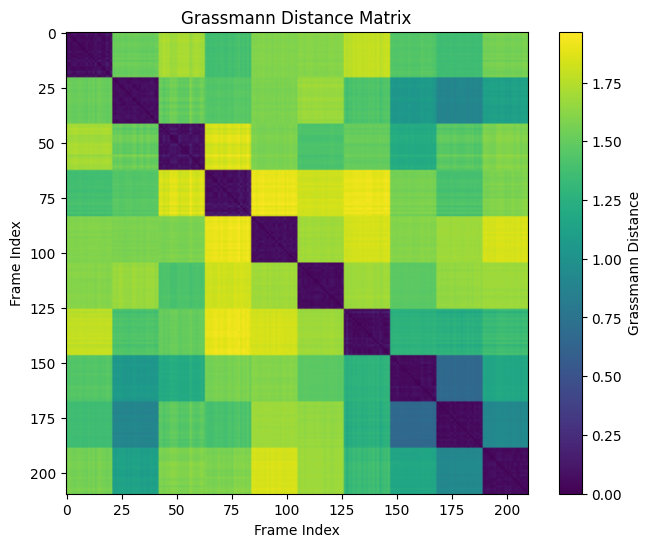

In [6]:
dist_matrix_grassmann = Grassmann.distance_matrix(frames, method='qr')
show_distance_matrix(dist_matrix_grassmann, method="Grassmann")

In [7]:
summary_grassmann, path_grassmann = make_clustering(
    frames, 
    dist_matrix=dist_matrix_grassmann, 
    metric_name="grassmann"
)

chemiscope.show_input(path_grassmann)

Using precomputed grassmann distance matrix (Shape: (210, 210))

Clustering Performance (Adjusted Rand Index) [grassmann]: 1.0000

Cluster Composition Summary:


cluster,unique_mols,mol_ids_in_cluster,representative_smiles,total_samples
u64,u32,list[str],str,u32
0,1,"[""qm9_1447""]","""[H]C(=O)O[C@]([H])(C([H])([H])[H])C([H])([H])C([H])([H])[H]""",21
1,1,"[""qm9_1449""]","""[H]C(=O)C([H])([H])[C@@]([H])(OC([H])([H])[H])C([H])([H])[H]""",21
2,1,"[""qm9_1237""]","""[H]OC([H])([H])C([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",21
3,1,"[""qm9_1478""]","""[H]C([H])([H])OC(=O)C([H])([H])C([H])([H])C([H])([H])[H]""",21
4,1,"[""qm9_1248""]","""[H]C([H])([H])OC([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",21
5,1,"[""qm9_1486""]","""[H]C([H])([H])C([H])([H])OC(=O)C([H])([H])C([H])([H])[H]""",21
6,1,"[""qm9_1474""]","""[H]C([H])([H])OC([H])([H])C(=O)C([H])([H])C([H])([H])[H]""",21
7,1,"[""qm9_1246""]","""[H]C([H])([H])C(=O)C([H])([H])OC([H])([H])C([H])([H])[H]""",21
8,1,"[""qm9_1476""]","""[H]OC([H])([H])C(=O)C([H])([H])C([H])([H])C([H])([H])[H]""",21



Chemiscope file successfully saved to: report/qm9/figures/grassmann/chemiscope_clustering_grassmann.json.gz


<ChemiscopeWidget(meta={'name': 'chemiscope_clustering_grassmann'}, structures=[{'size': 17, 'data': 'structur…

# Riemann Clustering

2026-03-10 13:44:11.754 | INFO     | src.non_euclidean:distance_matrix:267 - Computing Riemannian distance matrix for 210 frames (metric_type='log-euclidean').
Riemannian distances: 100%|██████████| 21945/21945 [00:00<00:00, 37812.07pair/s]
2026-03-10 13:44:12.347 | SUCCESS  | src.non_euclidean:distance_matrix:291 - Finished Riemannian distance matrix computation.
2026-03-10 13:44:12.348 | INFO     | src.non_euclidean:distance_matrix:267 - Computing Riemannian distance matrix for 210 frames (metric_type='affine-invariant').
Riemannian distances: 100%|██████████| 21945/21945 [00:00<00:00, 48944.71pair/s]
2026-03-10 13:44:12.802 | SUCCESS  | src.non_euclidean:distance_matrix:291 - Finished Riemannian distance matrix computation.


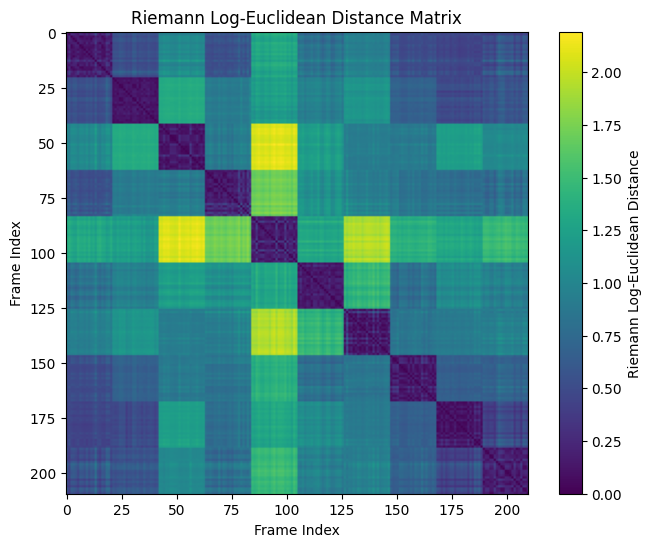

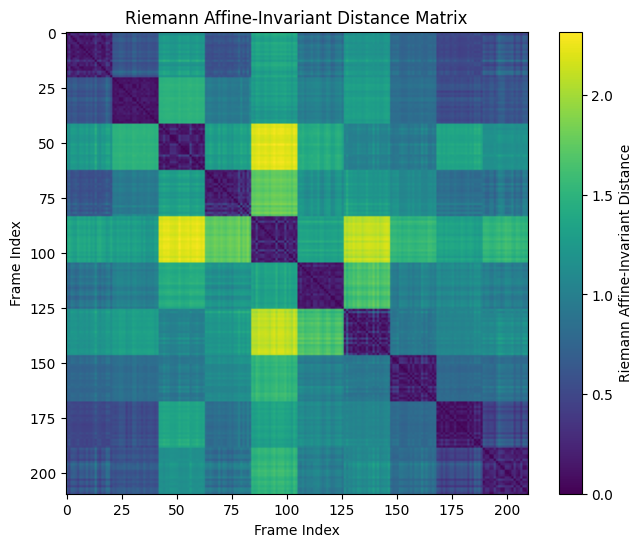

In [8]:
dist_matrix_eucliean_riemann = Riemann.distance_matrix(frames, metric_type='log-euclidean')
dist_matrix_affine_riemann = Riemann.distance_matrix(frames, metric_type='affine-invariant')

show_distance_matrix(dist_matrix_eucliean_riemann, method="Riemann Log-Euclidean")
show_distance_matrix(dist_matrix_affine_riemann, method="Riemann Affine-Invariant")

In [9]:
summary_riemann, path_riemann = make_clustering(
    frames, 
    dist_matrix=dist_matrix_eucliean_riemann, 
    metric_name="log-euclidean"
)

chemiscope.show_input(path_riemann)

Using precomputed log-euclidean distance matrix (Shape: (210, 210))

Clustering Performance (Adjusted Rand Index) [log-euclidean]: 1.0000

Cluster Composition Summary:


cluster,unique_mols,mol_ids_in_cluster,representative_smiles,total_samples
u64,u32,list[str],str,u32
0,1,"[""qm9_1486""]","""[H]C([H])([H])C([H])([H])OC(=O)C([H])([H])C([H])([H])[H]""",21
1,1,"[""qm9_1447""]","""[H]C(=O)O[C@]([H])(C([H])([H])[H])C([H])([H])C([H])([H])[H]""",21
2,1,"[""qm9_1474""]","""[H]C([H])([H])OC([H])([H])C(=O)C([H])([H])C([H])([H])[H]""",21
3,1,"[""qm9_1478""]","""[H]C([H])([H])OC(=O)C([H])([H])C([H])([H])C([H])([H])[H]""",21
4,1,"[""qm9_1244""]","""[H]C([H])([H])C(=O)OC([H])([H])C([H])([H])C([H])([H])[H]""",21
5,1,"[""qm9_1248""]","""[H]C([H])([H])OC([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",21
6,1,"[""qm9_1476""]","""[H]OC([H])([H])C(=O)C([H])([H])C([H])([H])C([H])([H])[H]""",21
7,1,"[""qm9_1246""]","""[H]C([H])([H])C(=O)C([H])([H])OC([H])([H])C([H])([H])[H]""",21
8,1,"[""qm9_1449""]","""[H]C(=O)C([H])([H])[C@@]([H])(OC([H])([H])[H])C([H])([H])[H]""",21



Chemiscope file successfully saved to: report/qm9/figures/grassmann/chemiscope_clustering_log-euclidean.json.gz


<ChemiscopeWidget(meta={'name': 'chemiscope_clustering_log-euclidean'}, structures=[{'size': 17, 'data': 'stru…

In [10]:
summary_affine_riemann, path_affine_riemann = make_clustering(
    frames,
    dist_matrix=dist_matrix_affine_riemann,
    metric_name="affine-invariant"
)

chemiscope.show_input(path_affine_riemann)

Using precomputed affine-invariant distance matrix (Shape: (210, 210))

Clustering Performance (Adjusted Rand Index) [affine-invariant]: 1.0000

Cluster Composition Summary:


cluster,unique_mols,mol_ids_in_cluster,representative_smiles,total_samples
u64,u32,list[str],str,u32
0,1,"[""qm9_1244""]","""[H]C([H])([H])C(=O)OC([H])([H])C([H])([H])C([H])([H])[H]""",21
1,1,"[""qm9_1246""]","""[H]C([H])([H])C(=O)C([H])([H])OC([H])([H])C([H])([H])[H]""",21
2,1,"[""qm9_1474""]","""[H]C([H])([H])OC([H])([H])C(=O)C([H])([H])C([H])([H])[H]""",21
3,1,"[""qm9_1449""]","""[H]C(=O)C([H])([H])[C@@]([H])(OC([H])([H])[H])C([H])([H])[H]""",21
4,1,"[""qm9_1486""]","""[H]C([H])([H])C([H])([H])OC(=O)C([H])([H])C([H])([H])[H]""",21
5,1,"[""qm9_1476""]","""[H]OC([H])([H])C(=O)C([H])([H])C([H])([H])C([H])([H])[H]""",21
6,1,"[""qm9_1478""]","""[H]C([H])([H])OC(=O)C([H])([H])C([H])([H])C([H])([H])[H]""",21
7,1,"[""qm9_1237""]","""[H]OC([H])([H])C([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",21
8,1,"[""qm9_1248""]","""[H]C([H])([H])OC([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",21



Chemiscope file successfully saved to: report/qm9/figures/grassmann/chemiscope_clustering_affine-invariant.json.gz


<ChemiscopeWidget(meta={'name': 'chemiscope_clustering_affine-invariant'}, structures=[{'size': 17, 'data': 's…

# Persistent Homology

2026-03-10 13:44:24.951 | INFO     | src.non_euclidean:distance_matrix:141 - Computing persistent homology distance matrix for 210 frames (backend='ripser', metric='bottleneck', max_homology_dim=2, dims=(0, 1, 2)).
2026-03-10 13:44:24.952 | INFO     | src.non_euclidean:compute_persistence_diagrams:82 - Computing persistence diagrams for 210 frames (backend='ripser', max_homology_dim=2).
Persistence diagrams: 100%|██████████| 210/210 [00:00<00:00, 3608.37frame/s]
2026-03-10 13:44:25.014 | SUCCESS  | src.non_euclidean:compute_persistence_diagrams:95 - Finished persistence diagram computation.
Persistence distances: 100%|██████████| 21945/21945 [00:50<00:00, 432.30pair/s]
2026-03-10 13:45:15.780 | SUCCESS  | src.non_euclidean:distance_matrix:157 - Finished persistent homology distance matrix computation.


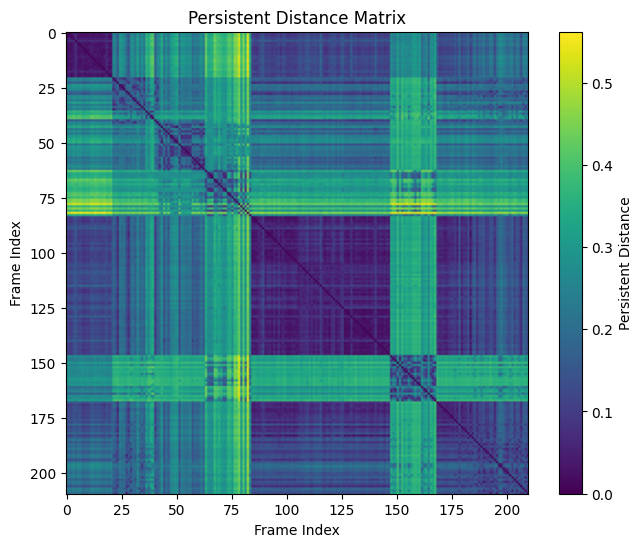

In [11]:
persistent_dist_matrix = PersistentHomology.distance_matrix(frames, metric="bottleneck")
show_distance_matrix(persistent_dist_matrix, method="Persistent")

2026-03-10 13:45:37.494 | INFO     | src.non_euclidean:compute_persistence_diagrams:82 - Computing persistence diagrams for 210 frames (backend='ripser', max_homology_dim=2).
Persistence diagrams: 100%|██████████| 210/210 [00:00<00:00, 2268.06frame/s]
2026-03-10 13:45:37.590 | SUCCESS  | src.non_euclidean:compute_persistence_diagrams:95 - Finished persistence diagram computation.


Atoms(symbols='OC4OCH10', pbc=False, initial_charges=...)


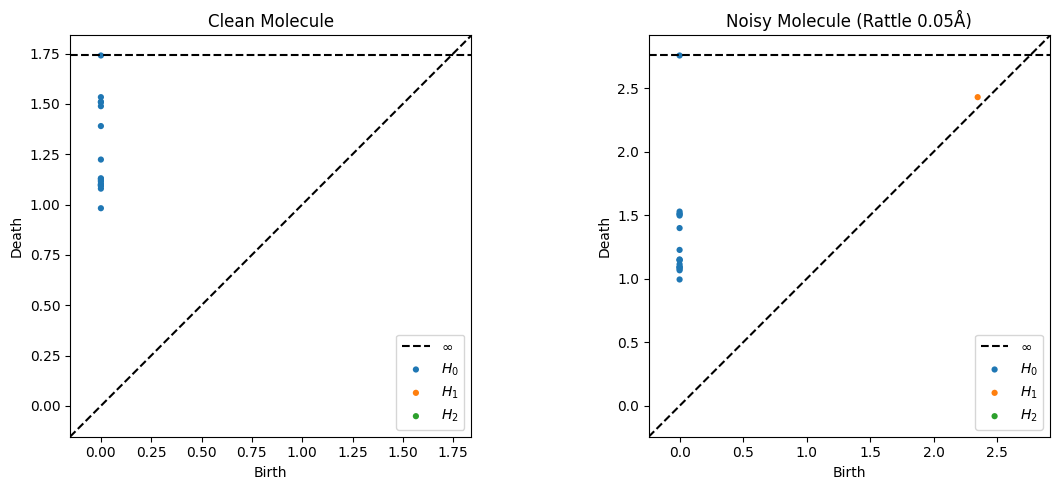

In [13]:
persistence_diagrams = PersistentHomology.compute_persistence_diagrams(frames, max_homology_dim=2)

print(frames[0])

base_molecules = [i for i, f in enumerate(frames) if f.info.get('frame_type', '') == 'base']

clean_dgm = persistence_diagrams[base_molecules[0]]
noisy_dgm = persistence_diagrams[base_molecules[0]+4]

def plot_stress_test_comparison(clean_dgm, noisy_dgm, rattle):
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    persim.plot_diagrams(list(clean_dgm.values()), ax=ax[0])
    ax[0].set_title("Clean Molecule")
    
    persim.plot_diagrams(list(noisy_dgm.values()), ax=ax[1])
    ax[1].set_title(f"Noisy Molecule (Rattle {rattle}Å)")
    
    plt.tight_layout()
    plt.show()

plot_stress_test_comparison(clean_dgm, noisy_dgm, rattle=0.05)

In [14]:
summary_persistent_homology, path_persistent_homology = make_clustering(
    frames, 
    dist_matrix=persistent_dist_matrix,
)

chemiscope.show_input(path_persistent_homology)

Using precomputed euclidean distance matrix (Shape: (210, 210))

Clustering Performance (Adjusted Rand Index) [euclidean]: 0.3192

Cluster Composition Summary:


cluster,unique_mols,mol_ids_in_cluster,representative_smiles,total_samples
u64,u32,list[str],str,u32
0,2,"[""qm9_1244"", ""qm9_1486""]","""[H]C([H])([H])C(=O)OC([H])([H])C([H])([H])C([H])([H])[H]""",13
1,2,"[""qm9_1246"", ""qm9_1248""]","""[H]C([H])([H])C(=O)C([H])([H])OC([H])([H])C([H])([H])[H]""",14
2,1,"[""qm9_1246""]","""[H]C([H])([H])C(=O)C([H])([H])OC([H])([H])C([H])([H])[H]""",10
3,1,"[""qm9_1476""]","""[H]OC([H])([H])C(=O)C([H])([H])C([H])([H])C([H])([H])[H]""",7
4,1,"[""qm9_1248""]","""[H]C([H])([H])OC([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",8
5,2,"[""qm9_1237"", ""qm9_1476""]","""[H]OC([H])([H])C([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",23
6,1,"[""qm9_1248""]","""[H]C([H])([H])OC([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",10
7,1,"[""qm9_1476""]","""[H]OC([H])([H])C(=O)C([H])([H])C([H])([H])C([H])([H])[H]""",12
8,3,"[""qm9_1244"", ""qm9_1478"", ""qm9_1486""]","""[H]C([H])([H])C(=O)OC([H])([H])C([H])([H])C([H])([H])[H]""",21



Chemiscope file successfully saved to: report/qm9/figures/grassmann/chemiscope_clustering_euclidean.json.gz


<ChemiscopeWidget(meta={'name': 'chemiscope_clustering_euclidean'}, structures=[{'size': 17, 'data': 'structur…